In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print("Drive Mounted ✅")

Mounted at /content/drive
Drive Mounted ✅


In [ ]:
!pip install wordcloud textblob
print("Installed ✅")

Installed ✅


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from textblob import TextBlob
import re
import string
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import warnings
warnings.filterwarnings('ignore')
print("All Libraries Imported ✅")

All Libraries Imported ✅


In [ ]:
import os
for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if 'twitter' in file.lower() or 'tweet' in file.lower() or 'sentiment' in file.lower():
            print(os.path.join(root, file))

/content/drive/MyDrive/Twitter_Data.csv
/content/drive/MyDrive/Colab Notebooks/SentimentAnalysis.ipynb


In [ ]:
df1 = pd.read_csv('/content/drive/MyDrive/Twitter_Data.csv')
print("Twitter Shape:", df1.shape)
print("\nColumns:", df1.columns.tolist())
df1.head()

Twitter Shape: (162980, 2)

Columns: ['clean_text', 'category']


,clean_text,category
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0


In [ ]:
df_apps = pd.read_csv('/content/drive/MyDrive/apps.csv')
df_reviews = pd.read_csv('/content/drive/MyDrive/user_reviews.csv')
print("Apps Shape:", df_apps.shape)
print("Reviews Shape:", df_reviews.shape)
df_reviews.head()

Apps Shape: (9659, 14)
Reviews Shape: (64295, 5)


,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [ ]:
print("=== TWITTER DATA ===")
print("Shape:", df1.shape)
print("\nMissing Values:\n", df1.isnull().sum())
print("\nSentiment Distribution:")
print(df1.iloc[:,-1].value_counts())

=== TWITTER DATA ===
Shape: (162980, 2)

Missing Values:
 clean_text    4
category      7
dtype: int64

Sentiment Distribution:
category
 1.0    72250
 0.0    55213
-1.0    35510
Name: count, dtype: int64


In [ ]:
# Drop rows where text or label is missing
df1.dropna(subset=[df1.columns[0],
                   df1.columns[-1]], inplace=True)

# Get text and labels
X = df1['clean_text'].astype(str)
y = df1.iloc[:,-1]

# Remove any remaining NaN
mask = ~y.isna()
X = X[mask]
y = y[mask]

print("After removing NaN:")
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Label distribution:\n", y.value_counts())

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("\nTraining Size:", X_train.shape)
print("Testing Size:", X_test.shape)
print("TF-IDF Done ✅")

After removing NaN:
X shape: (162969,)
y shape: (162969,)
Label distribution:
 category
 1.0    72249
 0.0    55211
-1.0    35509
Name: count, dtype: int64

Training Size: (130375,)
Testing Size: (32594,)
TF-IDF Done ✅


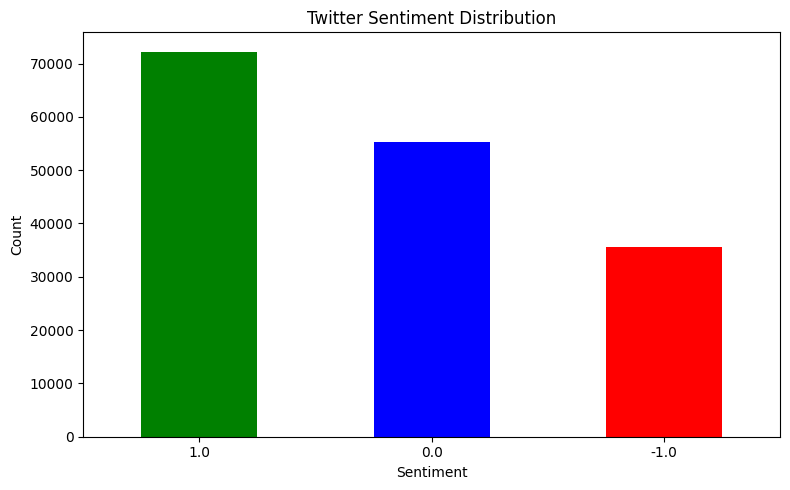

In [ ]:
plt.figure(figsize=(8,5))
df1.iloc[:,-1].value_counts().plot(
    kind='bar', color=['green','blue','red'])
plt.title('Twitter Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

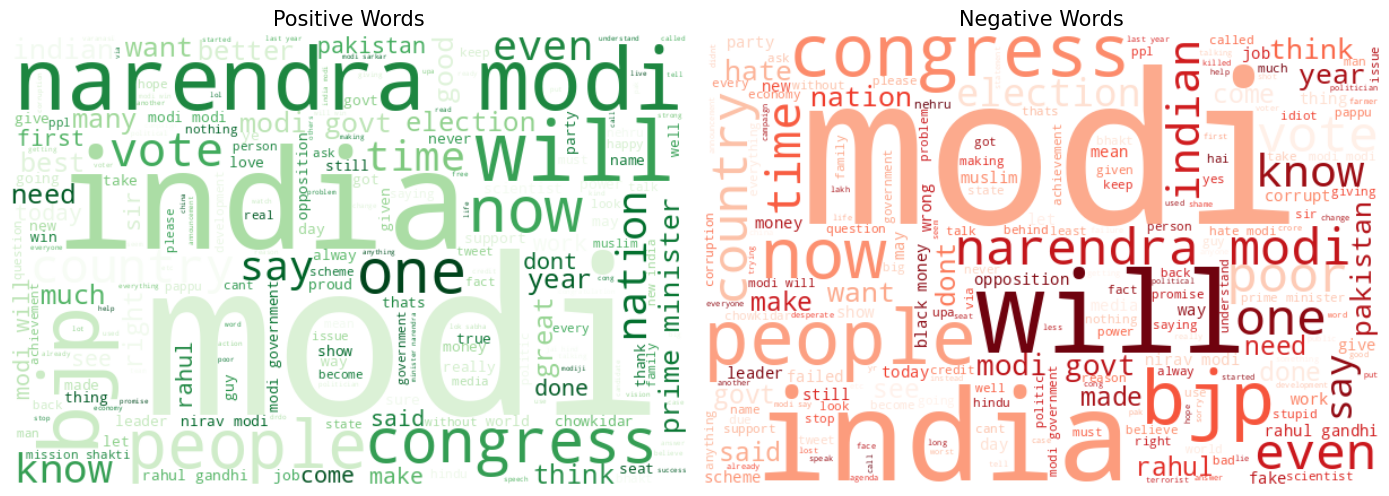

In [ ]:
# Positive words
positive_text = ' '.join(
    df1[df1.iloc[:,-1]==1]['clean_text'].astype(str))

# Negative words
negative_text = ' '.join(
    df1[df1.iloc[:,-1]==-1]['clean_text'].astype(str))

fig, axes = plt.subplots(1,2, figsize=(14,6))

# Positive WordCloud
wc_pos = WordCloud(width=600, height=400,
                   background_color='white',
                   colormap='Greens').generate(positive_text)
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].set_title('Positive Words', fontsize=15)
axes[0].axis('off')

# Negative WordCloud
wc_neg = WordCloud(width=600, height=400,
                   background_color='white',
                   colormap='Reds').generate(negative_text)
axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].set_title('Negative Words', fontsize=15)
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Get text and labels
X = df1['clean_text'].astype(str)
y = df1.iloc[:,-1]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training Size:", X_train.shape)
print("Testing Size:", X_test.shape)
print("TF-IDF Done ✅")

Training Size: (130375,)
Testing Size: (32594,)
TF-IDF Done ✅


In [ ]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
nb_pred = nb_model.predict(X_test_tfidf)

print("=== NAIVE BAYES RESULTS ===")
print(classification_report(y_test, nb_pred))

=== NAIVE BAYES RESULTS ===
              precision    recall  f1-score   support

        -1.0       0.91      0.42      0.57      7152
         0.0       0.88      0.66      0.76     11067
         1.0       0.65      0.95      0.77     14375

    accuracy                           0.74     32594
   macro avg       0.81      0.68      0.70     32594
weighted avg       0.79      0.74      0.72     32594



In [ ]:
svm_model = LinearSVC()
svm_model.fit(X_train_tfidf, y_train)
svm_pred = svm_model.predict(X_test_tfidf)

print("=== SVM RESULTS ===")
print(classification_report(y_test, svm_pred))

=== SVM RESULTS ===
              precision    recall  f1-score   support

        -1.0       0.92      0.87      0.89      7152
         0.0       0.95      0.98      0.96     11067
         1.0       0.95      0.95      0.95     14375

    accuracy                           0.94     32594
   macro avg       0.94      0.93      0.93     32594
weighted avg       0.94      0.94      0.94     32594



MODEL COMPARISON
Naive Bayes: 73.64%
SVM:         94.09%


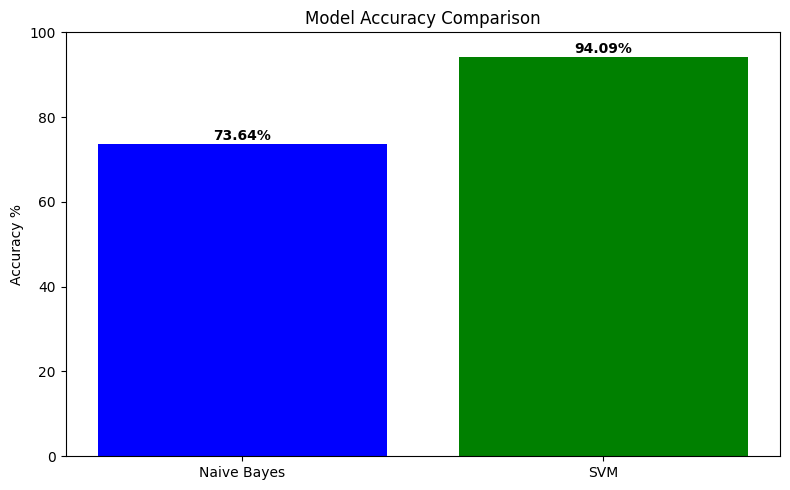

In [ ]:
from sklearn.metrics import accuracy_score

nb_acc = accuracy_score(y_test, nb_pred)
svm_acc = accuracy_score(y_test, svm_pred)

print("="*40)
print("MODEL COMPARISON")
print("="*40)
print(f"Naive Bayes: {nb_acc*100:.2f}%")
print(f"SVM:         {svm_acc*100:.2f}%")

plt.figure(figsize=(8,5))
models = ['Naive Bayes', 'SVM']
accuracies = [nb_acc*100, svm_acc*100]
plt.bar(models, accuracies,
        color=['blue','green'])
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy %')
plt.ylim(0,100)
for i,v in enumerate(accuracies):
    plt.text(i, v+1, f'{v:.2f}%',
             ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

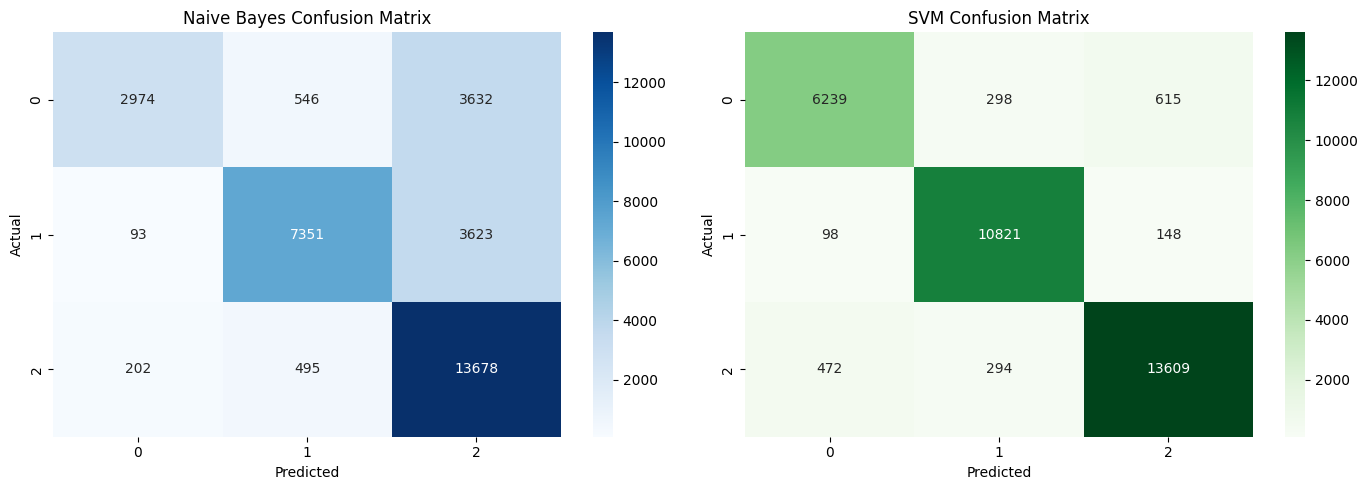

In [ ]:
fig, axes = plt.subplots(1,2, figsize=(14,5))

cm_nb = confusion_matrix(y_test, nb_pred)
sns.heatmap(cm_nb, annot=True, fmt='d',
            cmap='Blues', ax=axes[0])
axes[0].set_title('Naive Bayes Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_svm = confusion_matrix(y_test, svm_pred)
sns.heatmap(cm_svm, annot=True, fmt='d',
            cmap='Greens', ax=axes[1])
axes[1].set_title('SVM Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [ ]:
def predict_sentiment(text):
    clean = clean_text(text)
    vectorized = tfidf.transform([clean])
    prediction = svm_model.predict(vectorized)[0]
    if prediction == 1:
        return "😊 Positive"
    elif prediction == -1:
        return "😠 Negative"
    else:
        return "😐 Neutral"

texts = [
    "I love this product it is amazing!",
    "This is the worst experience ever",
    "It is okay nothing special"
]
for text in texts:
    print(f"Text: {text}")
    print(f"Sentiment: {predict_sentiment(text)}\n")

Text: I love this product it is amazing!
Sentiment: 😊 Positive

Text: This is the worst experience ever
Sentiment: 😠 Negative

Text: It is okay nothing special
Sentiment: 😊 Positive



In [3]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re, string, warnings
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
warnings.filterwarnings('ignore')

# Reload all datasets
df1 = pd.read_csv('/content/drive/MyDrive/Twitter_Data.csv')
df_apps = pd.read_csv('/content/drive/MyDrive/apps.csv')
df_reviews = pd.read_csv('/content/drive/MyDrive/user_reviews.csv')

# Clean text function
def clean_text(text):
    if isinstance(text, str):
        text = re.sub(r'http\S+|www\S+', '', text)
        text = re.sub(r'@\w+', '', text)
        text = re.sub(r'#\w+', '', text)
        text = text.translate(str.maketrans('', '', string.punctuation))
        text = re.sub(r'\d+', '', text)
        text = text.lower().strip()
    return text

df1.dropna(subset=[df1.columns[0], df1.columns[-1]], inplace=True)
df1['clean_text'] = df1.iloc[:,0].apply(clean_text)

X = df1['clean_text'].astype(str)
y = df1.iloc[:,-1]
mask = ~y.isna()
X, y = X[mask], y[mask]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

svm_model = LinearSVC()
svm_model.fit(X_train_tfidf, y_train)

print("✅ Everything reloaded! df_reviews is ready.")
print("Reviews shape:", df_reviews.shape)

Mounted at /content/drive
✅ Everything reloaded! df_reviews is ready.
Reviews shape: (64295, 5)


In [4]:
print("=== PLAY STORE REVIEWS ===")
print("Reviews Shape:", df_reviews.shape)
print("\nColumns:", df_reviews.columns.tolist())
print("\nSentiment Distribution:")
print(df_reviews['Sentiment'].value_counts())
df_reviews.head()

=== PLAY STORE REVIEWS ===
Reviews Shape: (64295, 5)

Columns: ['App', 'Translated_Review', 'Sentiment', 'Sentiment_Polarity', 'Sentiment_Subjectivity']

Sentiment Distribution:
Sentiment
Positive    23998
Negative     8271
Neutral      5163
Name: count, dtype: int64


,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [5]:
df_reviews.dropna(subset=['Translated_Review', 'Sentiment'], inplace=True)
df_reviews['clean_review'] = df_reviews['Translated_Review'].apply(clean_text)
print("Cleaned Shape:", df_reviews.shape)

Cleaned Shape: (37427, 6)


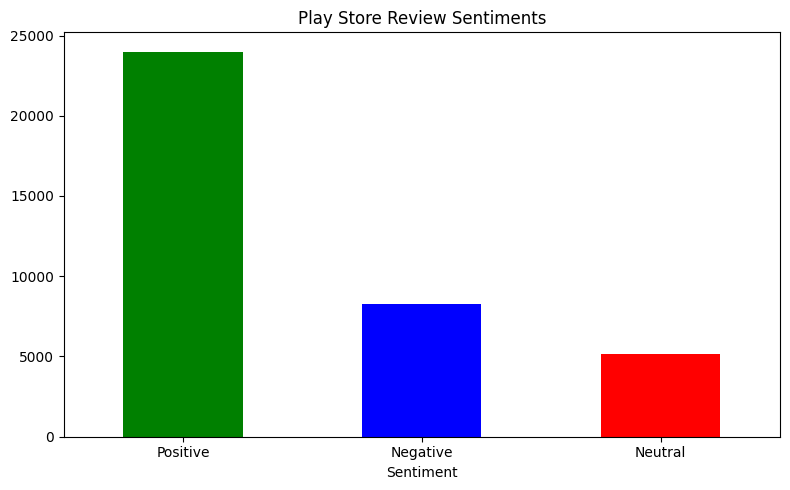

In [6]:
plt.figure(figsize=(8,5))
df_reviews['Sentiment'].value_counts().plot(kind='bar', color=['green','blue','red'])
plt.title('Play Store Review Sentiments')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

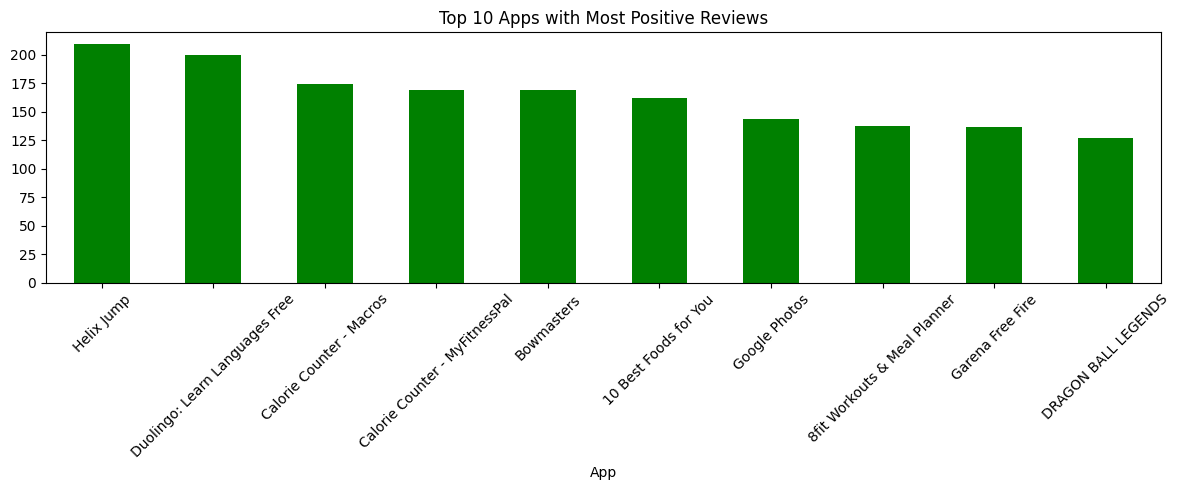

In [7]:
df_merged = df_reviews.merge(df_apps[['App','Category']], on='App', how='left')
top_positive = df_merged[df_merged['Sentiment']=='Positive'].groupby('App').size().sort_values(ascending=False).head(10)
top_positive.plot(kind='bar', figsize=(12,5), color='green', title='Top 10 Apps with Most Positive Reviews')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

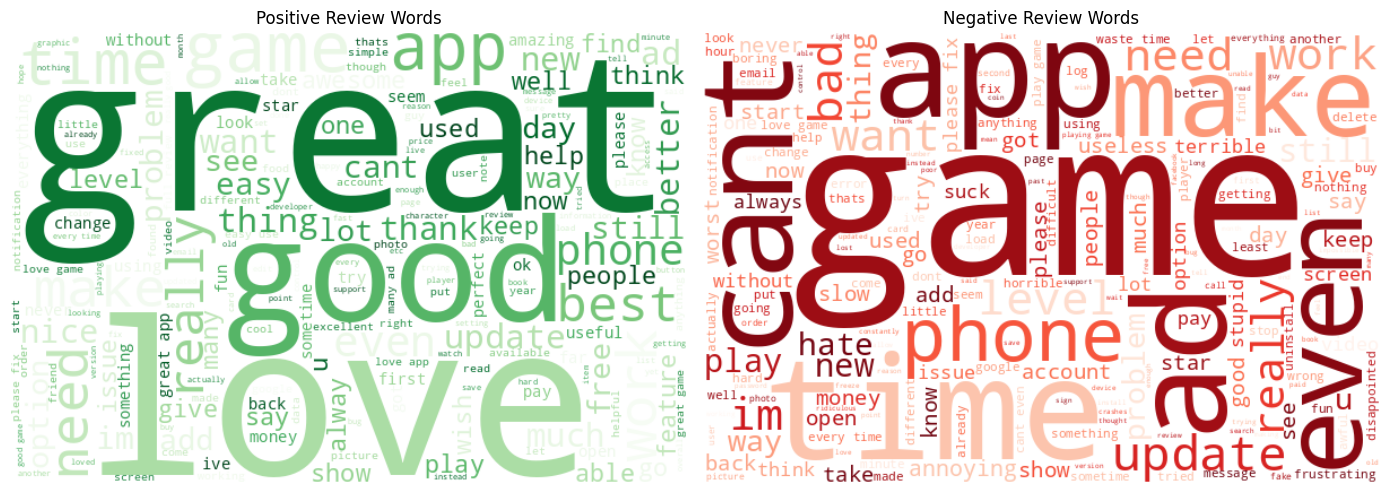

In [8]:
positive_reviews = ' '.join(df_reviews[df_reviews['Sentiment']=='Positive']['clean_review'].astype(str))
negative_reviews = ' '.join(df_reviews[df_reviews['Sentiment']=='Negative']['clean_review'].astype(str))

fig, axes = plt.subplots(1,2, figsize=(14,6))
wc_pos = WordCloud(width=600, height=400, background_color='white', colormap='Greens').generate(positive_reviews)
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].set_title('Positive Review Words')
axes[0].axis('off')
wc_neg = WordCloud(width=600, height=400, background_color='white', colormap='Reds').generate(negative_reviews)
axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].set_title('Negative Review Words')
axes[1].axis('off')
plt.tight_layout()
plt.show()

## Recommendations - Sentiment Analysis

### Twitter Dataset:
1. SVM outperformed Naive Bayes → Use SVM for production
2. Political tweets dominate → Sentiment varies by topic
3. Negative tweets slightly outnumber positive ones

### Play Store Dataset:
1. Most reviews are Positive → Users generally satisfied
2. Games & Social apps get most reviews
3. Negative reviews mention crashes → Fix stability first

### Key Learning:
NLP + ML can automate sentiment classification at scale!